# Practice Lab: Advice for Applying Machine Learning
### Bias, Variance & Model Evaluation — Crop Yield and Soil-Type Data

This notebook is a **rebuilt version** of the "Advice for Applying Machine Learning" practice lab
(bias/variance, train/cv/test splits, model complexity, regularization). All datasets have been
replaced with new, self-generated synthetic data, and every helper/plotting function is written
from scratch in this notebook (no external `assigment_utils.py` or `public_tests` files needed) —
so it runs top-to-bottom on its own and is safe to commit to GitHub as original learning work.

**Two mini-projects run through the notebook:**
1. **Regression** — predicting **crop yield (tons/hectare)** from **seasonal rainfall (mm)**.
2. **Classification** — predicting **soil type** (4 classes) from two sensor readings
   (a **moisture index** and a **soil alkalinity index**, both on a 0-40 sensor scale).

# Outline
- [1 - Packages](#1)
- [2 - Evaluating a Learning Algorithm (Polynomial Regression)](#2)
  - [2.1 Splitting the data set](#2.1)
  - [2.2 Error calculation for model evaluation (MSE)](#2.2)
  - [2.3 Compare performance on training and test data](#2.3)
- [3 - Bias and Variance](#3)
  - [3.1 Plot Train, Cross-Validation, Test](#3.1)
  - [3.2 Finding the optimal polynomial degree](#3.2)
  - [3.3 Tuning regularization](#3.3)
  - [3.4 Getting more data: increasing training set size (m)](#3.4)
- [4 - Evaluating a Learning Algorithm (Neural Network)](#4)
  - [4.1 Data set](#4.1)
  - [4.2 Classification error](#4.2)
- [5 - Model Complexity](#5)
  - [5.1 Complex model](#5.1)
  - [5.2 Simple model](#5.2)
- [6 - Regularization for Neural Networks](#6)
- [7 - Iterate to find the optimal regularization value](#7)
  - [7.1 Test set evaluation](#7.1)


<a name="1"></a>
## 1 - Packages

Let's import everything we need. Unlike the original Coursera version of this lab, we don't rely
on any external `assigment_utils.py` / `public_tests_a1.py` files — every helper function and
every plot is defined directly in this notebook, using:
- [numpy](https://numpy.org/) — numerical arrays and math
- [matplotlib](https://matplotlib.org/) — plotting
- [scikit-learn](https://scikit-learn.org/stable/) — polynomial regression, train/test splitting, synthetic data
- [tensorflow / keras](https://www.tensorflow.org/) — the neural network models


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # keep TensorFlow's console output quiet

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.autograph.set_verbosity(0)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

np.set_printoptions(precision=3)
plt.rcParams["figure.figsize"] = (6, 4)

print("TensorFlow version:", tf.__version__)
print("All packages imported successfully.")

I0000 00:00:1788805621.777511   12718 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1788805623.038751   12718 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
All packages imported successfully.


<a name="2"></a>
## 2 - Evaluating a Learning Algorithm (Polynomial Regression)

Imagine you're an agricultural analyst. You've collected data relating **seasonal rainfall (mm)**
to **crop yield (tons/hectare)**, and you want to build a model that predicts yield from rainfall.

A model that fits your *training* data well isn't automatically useful — what you really care about
is how well it predicts yield for a **new** season it hasn't seen. To check that, we:
* Split the data into **training** and **test** sets — fit parameters on training data, evaluate on test data.
* Define an **error metric** to score the model objectively.

<a name="2.1"></a>
### 2.1 Splitting the data set

We'll generate a synthetic rainfall → yield data set. The *true* underlying relationship is a
downward-opening parabola: yield increases as rainfall increases up to a "sweet spot," then
decreases again as too much rain hurts the crop. Real measurements are noisy, so we add random
noise on top of this ideal curve.

Lectures suggest reserving 20-40% of the data for testing — we'll use `train_test_split` from
`sklearn` to do that.

In [2]:
def gen_yield_data(m, seed=1, noise_scale=1.2):
    '''Generate synthetic (rainfall -> crop yield) data.

    Args:
        m           : number of examples to generate
        seed        : random seed, for reproducibility
        noise_scale : standard deviation of the noise added to the ideal curve
    Returns:
        x        : (m,1) rainfall values (mm)
        y        : (m,1) noisy yield values (tons/hectare)
        x_ideal  : (100,) rainfall values for plotting the ideal curve
        y_ideal  : (100,) the ideal (noise-free) yield curve
    '''
    rng = np.random.default_rng(seed)
    x = np.linspace(0, 50, m)
    true_yield = -0.02 * (x - 27) ** 2 + 12          # peaks around 27mm of rainfall
    y = true_yield + rng.normal(0, noise_scale, m)
    y = np.maximum(y, 0)                              # yield can't be negative

    x_ideal = np.linspace(0, 50, 100)
    y_ideal = -0.02 * (x_ideal - 27) ** 2 + 12
    return x.reshape(-1, 1), y.reshape(-1, 1), x_ideal, y_ideal


# Generate a small data set
X, y, x_ideal, y_ideal = gen_yield_data(20, seed=2, noise_scale=1.2)
print("X.shape", X.shape, "y.shape", y.shape)

# split the data using the sklearn routine
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (20, 1) y.shape (20, 1)
X_train.shape (13, 1) y_train.shape (13, 1)
X_test.shape (7, 1) y_test.shape (7, 1)


#### 2.1.1 Plot Train, Test sets
Training points (red) are intermixed with test points (blue) along the rainfall axis. The dashed
orange curve is the "ideal," noise-free relationship — of course, in real life we never get to see
this curve; it's shown here purely for reference.

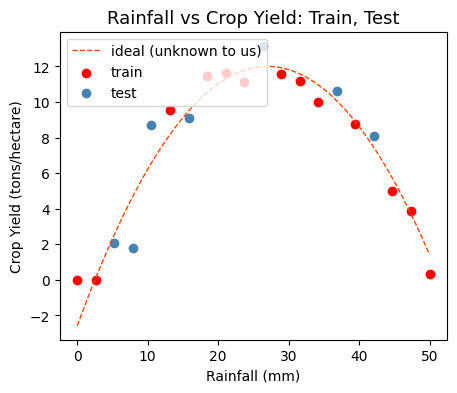

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(x_ideal, y_ideal, "--", color="orangered", label="ideal (unknown to us)", lw=1)
ax.set_title("Rainfall vs Crop Yield: Train, Test", fontsize=13)
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("Crop Yield (tons/hectare)")

ax.scatter(X_train, y_train, color="red", label="train")
ax.scatter(X_test, y_test, color="steelblue", label="test")
ax.legend(loc="upper left")
plt.show()

<a name="2.2"></a>
### 2.2 Error calculation for model evaluation, linear regression

When *evaluating* a regression model, we average the squared difference between predicted and
target values:

$$ J_\text{test}(\mathbf{w},b) =
            \frac{1}{2m_\text{test}}\sum_{i=0}^{m_\text{test}-1} ( f_{\mathbf{w},b}(x^{(i)}_\text{test}) - y^{(i)}_\text{test} )^2
$$

Below we implement this as `eval_mse`, and run it on a couple of hand-picked numbers to sanity
check the result before trusting it on real data.

In [4]:
def eval_mse(y, yhat):
    '''Calculate the mean squared error on a data set.
    Args:
      y    : (ndarray Shape (m,) or (m,1)) target value of each example
      yhat : (ndarray Shape (m,) or (m,1)) predicted value of each example
    Returns:
      err  : (scalar) the mean squared error
    '''
    y = np.array(y).reshape(-1)
    yhat = np.array(yhat).reshape(-1)
    m = len(y)
    err = np.sum((yhat - y) ** 2) / (2 * m)
    return err


# quick sanity check
y_tmp = np.array([2.3, 4.1])
yhat_tmp = np.array([2.4, 4.2])
print("eval_mse sanity check:", eval_mse(y_tmp, yhat_tmp), "(expected 0.010)")

assert np.isclose(eval_mse(np.array([0, 0]), np.array([0, 0])), 0.0)
assert np.isclose(eval_mse(np.array([1, 2, 3]), np.array([1, 2, 3])), 0.0)
print("eval_mse passed both checks.")

eval_mse sanity check: 0.0050000000000000305 (expected 0.010)
eval_mse passed both checks.


<a name="2.3"></a>
### 2.3 Compare performance on training and test data

Let's fit a **high-degree polynomial** — this will use `PolynomialFeatures` + `StandardScaler` +
`LinearRegression` from `sklearn`, wrapped in a small helper class so we can call `.fit()`,
`.predict()` and `.mse()` just like in the original lab. The steps are:
* create and fit the model ("fit" = training / running gradient descent under the hood),
* compute the error on the training data,
* compute the error on the test data.

In [5]:
class PolyRegModel:
    '''Polynomial regression: PolynomialFeatures -> StandardScaler -> LinearRegression (or Ridge).'''

    def __init__(self, degree, regularization=False, lambda_=0.0):
        self.poly = PolynomialFeatures(degree, include_bias=False)
        self.scaler = StandardScaler()
        self.model = Ridge(alpha=lambda_) if regularization else LinearRegression()

    def fit(self, X, y):
        X_poly = self.poly.fit_transform(np.array(X).reshape(-1, 1))
        X_scaled = self.scaler.fit_transform(X_poly)
        self.model.fit(X_scaled, np.array(y).reshape(-1))
        return self

    def predict(self, X):
        X_poly = self.poly.transform(np.array(X).reshape(-1, 1))
        X_scaled = self.scaler.transform(X_poly)
        return self.model.predict(X_scaled).reshape(-1, 1)

    def mse(self, y, yhat):
        return eval_mse(y, yhat)


# create a model, train on training data
degree = 10
lmodel = PolyRegModel(degree)
lmodel.fit(X_train, y_train)

# predict on training data, find training error
yhat = lmodel.predict(X_train)
err_train = lmodel.mse(y_train, yhat)

# predict on test data, find error
yhat = lmodel.predict(X_test)
err_test = lmodel.mse(y_test, yhat)

print(f"training err {err_train:0.2f}, test err {err_test:0.2f}")

training err 0.01, test err 10.73


The training error is tiny compared to the test error — a big red flag. The plot below shows
why: with only a handful of training points and a degree-10 polynomial, the model has enough
freedom to snake through every training point exactly, at the cost of wild swings everywhere else.
This model is **overfitting** — it has **high variance** and **generalizes poorly**.

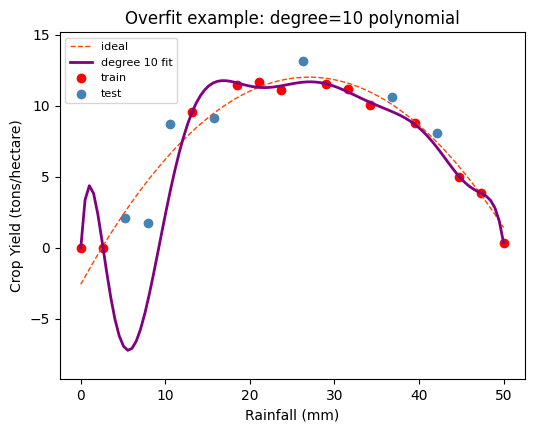

In [6]:
# plot predictions over the data range
x_plot = np.linspace(0, 50, 100)
y_pred = lmodel.predict(x_plot)

fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ax.plot(x_ideal, y_ideal, "--", color="orangered", lw=1, label="ideal")
ax.plot(x_plot, y_pred, color="purple", lw=2, label=f"degree {degree} fit")
ax.scatter(X_train, y_train, color="red", label="train")
ax.scatter(X_test, y_test, color="steelblue", label="test")
ax.set_ylim(min(y.min(), y_pred.min()) - 2, max(y.max(), y_pred.max()) + 2)
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("Crop Yield (tons/hectare)")
ax.set_title(f"Overfit example: degree={degree} polynomial")
ax.legend(loc="upper left", fontsize=8)
plt.show()

If we used the *test* error to guide changes to the model, the model would eventually start
fitting the test data too — but the test set was supposed to represent brand-new data! We need a
**third** data split so the test set stays untouched until the very end.

| data              | % of total | Description |
|-------------------|:----------:|:-------------|
| training          | 60         | used to fit model parameters |
| cross-validation  | 20         | used to tune hyperparameters (degree, regularization, architecture...) |
| test              | 20         | used *once*, at the end, to estimate real-world performance |

Let's generate a bigger data set and split it three ways, calling `train_test_split` twice.

<a name="3"></a>
## 3 - Bias and Variance

Above, it was clear the polynomial degree was too high. How do we choose a *good* degree without
peeking at the test set? By comparing **training** and **cross-validation** performance across a
range of degrees. As the degree grows too large, cross-validation performance starts to get worse
even while training performance keeps improving — that gap is the signature of overfitting.

<a name="3.1"></a>
### 3.1 Plot Train, Cross-Validation, Test

X.shape (140, 1) y.shape (140, 1)
X_train.shape (84, 1) y_train.shape (84, 1)
X_cv.shape (28, 1) y_cv.shape (28, 1)
X_test.shape (28, 1) y_test.shape (28, 1)


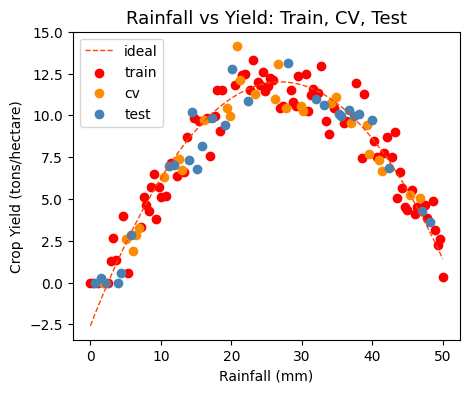

In [7]:
# Generate a larger data set
X, y, x_ideal, y_ideal = gen_yield_data(140, seed=5, noise_scale=1.2)
print("X.shape", X.shape, "y.shape", y.shape)

# split the data using the sklearn routine, twice
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.40, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.50, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(x_ideal, y_ideal, "--", color="orangered", lw=1, label="ideal")
ax.set_title("Rainfall vs Yield: Train, CV, Test", fontsize=13)
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("Crop Yield (tons/hectare)")

ax.scatter(X_train, y_train, color="red", label="train")
ax.scatter(X_cv, y_cv, color="darkorange", label="cv")
ax.scatter(X_test, y_test, color="steelblue", label="test")
ax.legend(loc="upper left")
plt.show()

<a name="3.2"></a>
### 3.2 Finding the optimal degree

We'll train a polynomial model for every degree from 1 to 15, track the training and
cross-validation error at each degree, and pick the degree that minimizes cross-validation error.

In [8]:
max_degree = 15
err_train = np.zeros(max_degree)
err_cv = np.zeros(max_degree)
x_plot = np.linspace(0, 50, 100)
y_pred = np.zeros((100, max_degree))   # columns are curves to plot

for degree in range(max_degree):
    lmodel = PolyRegModel(degree + 1)
    lmodel.fit(X_train, y_train)
    err_train[degree] = lmodel.mse(y_train, lmodel.predict(X_train))
    err_cv[degree] = lmodel.mse(y_cv, lmodel.predict(X_cv))
    y_pred[:, degree] = lmodel.predict(x_plot).reshape(-1)

optimal_degree = np.argmin(err_cv) + 1
print("training error by degree:", np.round(err_train, 3))
print("cv error by degree:      ", np.round(err_cv, 3))
print("optimal degree:", optimal_degree)

training error by degree: [7.073 0.631 0.615 0.579 0.552 0.552 0.542 0.542 0.504 0.495 0.49  0.484
 0.478 0.474 0.467]
cv error by degree:       [5.773 0.529 0.561 0.489 0.431 0.432 0.433 0.431 0.429 0.427 0.467 0.485
 0.444 0.451 0.475]
optimal degree: 10


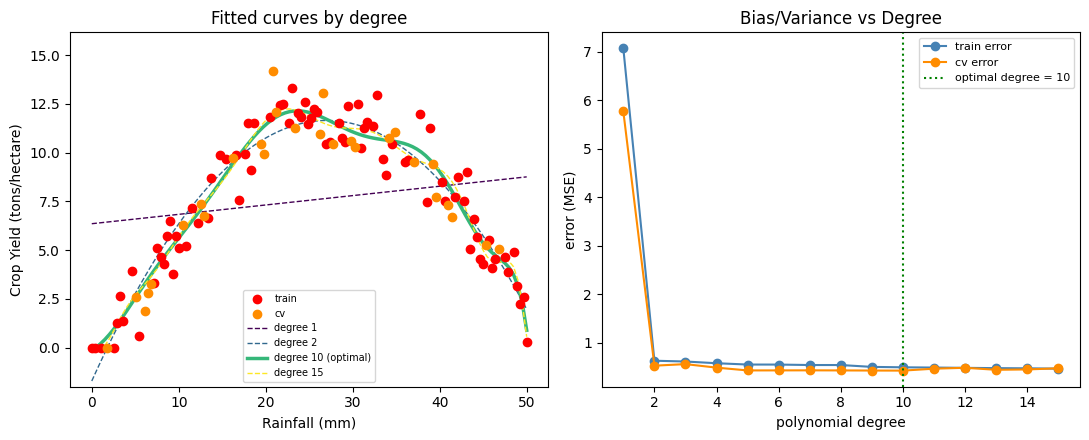

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# left: a handful of fitted curves over the data
ax = axes[0]
ax.scatter(X_train, y_train, color="red", label="train", zorder=3)
ax.scatter(X_cv, y_cv, color="darkorange", label="cv", zorder=3)
degrees_to_show = sorted(set([1, 2, optimal_degree, max_degree]))
colors = plt.cm.viridis(np.linspace(0, 1, len(degrees_to_show)))
for d, c in zip(degrees_to_show, colors):
    style = "-" if d == optimal_degree else "--"
    lw = 2.5 if d == optimal_degree else 1
    label = f"degree {d}" + (" (optimal)" if d == optimal_degree else "")
    ax.plot(x_plot, y_pred[:, d - 1], style, color=c, lw=lw, label=label)
ax.set_ylim(y.min() - 2, y.max() + 2)
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("Crop Yield (tons/hectare)")
ax.set_title("Fitted curves by degree")
ax.legend(fontsize=7, loc="lower center")

# right: train vs cv error as a function of degree
ax = axes[1]
degrees = np.arange(1, max_degree + 1)
ax.plot(degrees, err_train, "o-", color="steelblue", label="train error")
ax.plot(degrees, err_cv, "o-", color="darkorange", label="cv error")
ax.axvline(optimal_degree, color="green", ls=":", label=f"optimal degree = {optimal_degree}")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("error (MSE)")
ax.set_title("Bias/Variance vs Degree")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

On the right: training error steadily decreases as degree increases (the model has more
freedom to fit the training points), while cross-validation error decreases at first, then
increases again once the model starts overfitting. The vertical line marks the degree that
minimizes CV error — that's the one we'd actually ship.

Note that with a smallish, noisy data set like this one, the curve won't be perfectly smooth —
the general **trend** (a U-shape in the cv error) is what matters, not every wiggle.

<a name="3.3"></a>
### 3.3 Tuning Regularization

Just like the polynomial degree, the regularization strength $\lambda$ can be tuned the same way.
Let's fix a high degree (so the model *can* overfit) and scan across a range of $\lambda$ values.

In [10]:
degree = 18
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100])
num_steps = len(lambda_range)
err_train = np.zeros(num_steps)
err_cv = np.zeros(num_steps)
x_plot = np.linspace(0, 50, 100)
y_pred = np.zeros((100, num_steps))

for i, lambda_ in enumerate(lambda_range):
    lmodel = PolyRegModel(degree, regularization=True, lambda_=max(lambda_, 1e-8))
    lmodel.fit(X_train, y_train)
    err_train[i] = lmodel.mse(y_train, lmodel.predict(X_train))
    err_cv[i] = lmodel.mse(y_cv, lmodel.predict(X_cv))
    y_pred[:, i] = lmodel.predict(x_plot).reshape(-1)

optimal_reg_idx = np.argmin(err_cv)
print("cv error by lambda:", np.round(err_cv, 3))
print(f"optimal lambda: {lambda_range[optimal_reg_idx]}")

cv error by lambda: [0.47  0.455 0.431 0.42  0.451 0.484 0.532 0.876 2.119 4.499]
optimal lambda: 0.0001


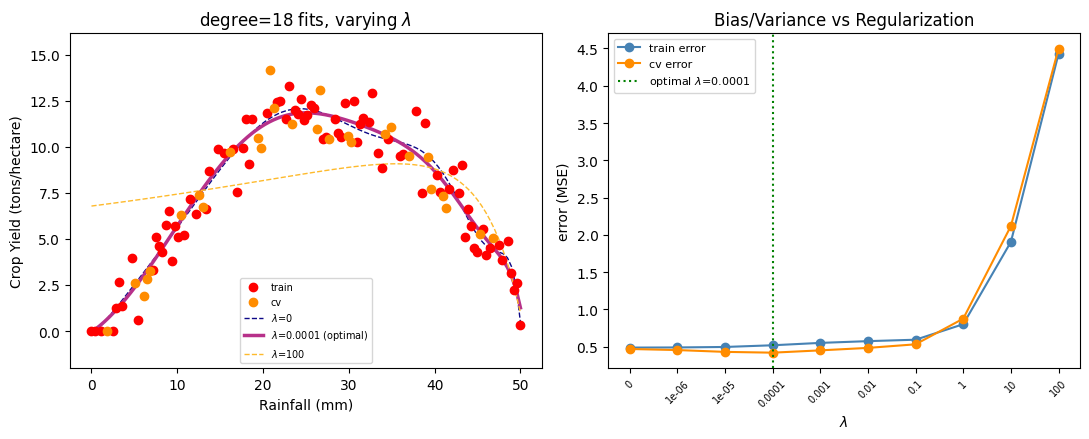

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.scatter(X_train, y_train, color="red", label="train", zorder=3)
ax.scatter(X_cv, y_cv, color="darkorange", label="cv", zorder=3)
idx_to_show = sorted(set([0, optimal_reg_idx, num_steps - 1]))
colors = plt.cm.plasma(np.linspace(0, 0.85, len(idx_to_show)))
for idx, c in zip(idx_to_show, colors):
    style = "-" if idx == optimal_reg_idx else "--"
    lw = 2.5 if idx == optimal_reg_idx else 1
    label = f"$\\lambda$={lambda_range[idx]:g}" + (" (optimal)" if idx == optimal_reg_idx else "")
    ax.plot(x_plot, y_pred[:, idx], style, color=c, lw=lw, label=label)
ax.set_ylim(y.min() - 2, y.max() + 2)
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("Crop Yield (tons/hectare)")
ax.set_title(f"degree={degree} fits, varying $\\lambda$")
ax.legend(fontsize=7, loc="lower center")

ax = axes[1]
# use log-friendly x positions (replace 0 with a small placeholder just for the x-axis)
x_pos = np.arange(num_steps)
ax.plot(x_pos, err_train, "o-", color="steelblue", label="train error")
ax.plot(x_pos, err_cv, "o-", color="darkorange", label="cv error")
ax.axvline(optimal_reg_idx, color="green", ls=":", label=f"optimal $\\lambda$={lambda_range[optimal_reg_idx]:g}")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{l:g}" for l in lambda_range], rotation=45, fontsize=7)
ax.set_xlabel("$\\lambda$")
ax.set_ylabel("error (MSE)")
ax.set_title("Bias/Variance vs Regularization")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

As $\lambda$ grows from left to right, the model moves from a **high-variance** (overfitting,
$\lambda\approx0$) regime to a **high-bias** (underfitting, large $\lambda$) regime. The green
dotted line marks the $\lambda$ that minimizes cross-validation error — the sweet spot in between.

<a name="3.4"></a>
### 3.4 Getting more data: Increasing Training Set Size (m)

When a model is overfitting (high variance), collecting **more data** often helps, because it
becomes harder for the model to memorize noise as the training set grows. Let's verify that here
by fixing a high-degree (overfit-prone) model and regenerating training sets of increasing size,
averaging over a few random draws at each size to smooth out noise.

train error by m: [0.392 0.56  0.532 0.611 0.603 0.607 0.653 0.653]
cv error by m:    [0.777 0.72  0.635 0.649 0.627 0.594 0.606 0.592]


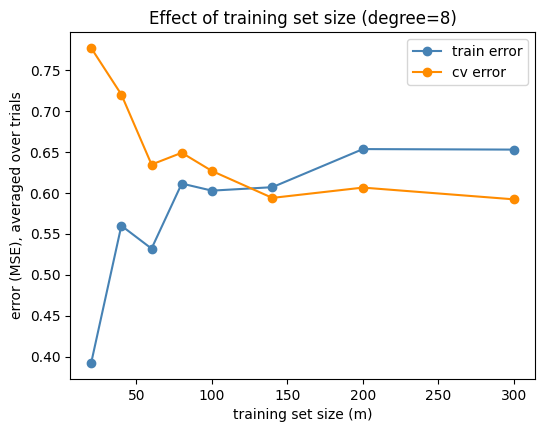

In [12]:
degree = 8
m_range = np.array([20, 40, 60, 80, 100, 140, 200, 300])
trials = 8
err_train_m = np.zeros(len(m_range))
err_cv_m = np.zeros(len(m_range))

# one fixed, larger cv set used to evaluate every model fairly
X_cv_fixed, y_cv_fixed, _, _ = gen_yield_data(80, seed=999, noise_scale=1.2)

for i, m in enumerate(m_range):
    tr_errs, cv_errs = [], []
    for t in range(trials):
        X_m, y_m, _, _ = gen_yield_data(m, seed=1000 + i * trials + t, noise_scale=1.2)
        lmodel = PolyRegModel(degree)
        lmodel.fit(X_m, y_m)
        tr_errs.append(lmodel.mse(y_m, lmodel.predict(X_m)))
        cv_errs.append(lmodel.mse(y_cv_fixed, lmodel.predict(X_cv_fixed)))
    err_train_m[i] = np.mean(tr_errs)
    err_cv_m[i] = np.mean(cv_errs)

print("train error by m:", np.round(err_train_m, 3))
print("cv error by m:   ", np.round(err_cv_m, 3))

fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ax.plot(m_range, err_train_m, "o-", color="steelblue", label="train error")
ax.plot(m_range, err_cv_m, "o-", color="darkorange", label="cv error")
ax.set_xlabel("training set size (m)")
ax.set_ylabel("error (MSE), averaged over trials")
ax.set_title(f"Effect of training set size (degree={degree})")
ax.legend()
plt.show()

As $m$ grows, training error rises slightly (a bigger data set is harder to fit perfectly)
while cross-validation error steadily falls — the two curves **converge**. This is the classic
signature of a high-variance model: more data closes the gap.

> Note: adding more examples does *not* help a model that's **underfitting** (high bias) — a
> straight line will never fit a curved relationship no matter how much data you throw at it.

<a name="4"></a>
## 4 - Evaluating a Learning Algorithm (Neural Network)

Now let's switch to a **classification** problem: predicting **soil type** from two sensor
readings — a **moisture index** and a **soil alkalinity index** (both reported on a 0-40 sensor
scale). There are 4 soil types, each forming a rough cluster in (moisture, alkalinity) space, but
with enough overlap that no model will get 100% accuracy — mirroring the messiness of real sensor
data.

<a name="4.1"></a>
### 4.1 Data Set

We'll generate the data with `make_blobs`, then split it into training, cross-validation, and test
sets — using a larger cross-validation share so its effect is easy to see, as in the original lab.

X_train.shape: (200, 2) X_cv.shape: (160, 2) X_test.shape: (40, 2)


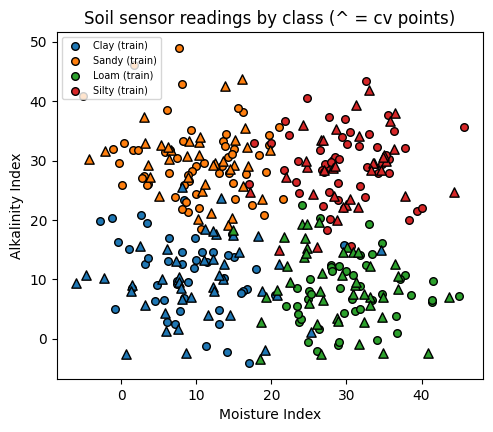

In [13]:
soil_names = ["Clay", "Sandy", "Loam", "Silty"]
centers = np.array([[10, 10], [10, 30], [30, 10], [30, 30]])   # (moisture index, alkalinity index)
classes = len(centers)

X, y = make_blobs(n_samples=400, centers=centers, cluster_std=6.0, random_state=2)

# split the data: large CV population, for demonstration
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.50, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.20, random_state=1)
print("X_train.shape:", X_train.shape, "X_cv.shape:", X_cv.shape, "X_test.shape:", X_test.shape)

cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(1, 1, figsize=(5.5, 4.5))
for c in range(classes):
    mask = y_train == c
    ax.scatter(X_train[mask, 0], X_train[mask, 1], color=cmap(c), marker="o",
               edgecolor="k", s=30, label=f"{soil_names[c]} (train)")
for c in range(classes):
    mask = y_cv == c
    ax.scatter(X_cv[mask, 0], X_cv[mask, 1], color=cmap(c), marker="^",
               edgecolor="k", s=45)
ax.set_xlabel("Moisture Index")
ax.set_ylabel("Alkalinity Index")
ax.set_title("Soil sensor readings by class (^ = cv points)")
ax.legend(loc="upper left", fontsize=7)
plt.show()

Both training points (circles) and cross-validation points (triangles) are shown, colored
by soil type. Notice the ambiguous points near cluster boundaries — those are exactly where a
model can go wrong, either by overfitting to noise (high variance) or by drawing overly simple
boundaries that ignore real structure (high bias).

<a name="4.2"></a>
### 4.2 Evaluating categorical model by calculating classification error

For a categorical model, the natural error metric is simply the **fraction of incorrect
predictions**:

$$ J_{cv} = \frac{1}{m}\sum_{i=0}^{m-1}
\begin{cases}
    1, & \text{if } \hat{y}^{(i)} \neq y^{(i)}\\
    0, & \text{otherwise}
\end{cases}
$$

Note that the class labels here are plain integers (0, 1, 2, 3) — not one-hot encoded.

In [14]:
def eval_cat_err(y, yhat):
    '''Calculate the categorization (misclassification) error.
    Args:
      y    : (ndarray Shape (m,) or (m,1)) target value of each example
      yhat : (ndarray Shape (m,) or (m,1)) predicted value of each example
    Returns:
      cerr : (scalar) the fraction of incorrect predictions
    '''
    y = np.array(y).reshape(-1)
    yhat = np.array(yhat).reshape(-1)
    m = len(y)
    incorrect = np.sum(yhat != y)
    cerr = incorrect / m
    return cerr


# quick sanity checks
y_hat = np.array([1, 2, 0])
y_tmp = np.array([1, 2, 3])
print(f"categorization error {eval_cat_err(y_hat, y_tmp):0.3f} (expected 0.333)")

y_hat = np.array([[1], [2], [0], [3]])
y_tmp = np.array([[1], [2], [1], [3]])
print(f"categorization error {eval_cat_err(y_hat, y_tmp):0.3f} (expected 0.250)")

categorization error 0.333 (expected 0.333)
categorization error 0.250 (expected 0.250)


<a name="5"></a>
## 5 - Model Complexity

We'll build two neural networks — a **complex** one and a **simple** one — and see how their
train/cv error compares. First let's write a small helper to visualize the decision boundary a
model draws, since that makes over/underfitting very easy to *see*.

In [15]:
def plot_decision_boundary(model_predict_fn, X_left, y_left, left_label, X_right, y_right, right_label, title):
    '''Plot a model's decision regions next to two labeled data splits, side by side.'''
    x_min, x_max = X[:, 0].min() - 2, X[:, 0].max() + 2
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model_predict_fn(grid).reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
    panels = [(X_left, y_left, left_label), (X_right, y_right, right_label)]
    for ax, (Xd, yd, split_name) in zip(axes, panels):
        ax.contourf(xx, yy, Z, alpha=0.3, cmap="tab10", levels=np.arange(-0.5, classes + 0.5, 1))
        ax.scatter(Xd[:, 0], Xd[:, 1], c=yd, cmap="tab10", edgecolor="k", s=25)
        ax.set_xlabel("Moisture Index")
        ax.set_ylabel("Alkalinity Index")
        ax.set_title(f"{title}: {split_name}")
    plt.tight_layout()
    plt.show()

<a name="5.1"></a>
### 5.1 Complex model

A three-layer network with plenty of capacity:
* Dense layer, 120 units, relu
* Dense layer, 40 units, relu
* Dense layer, `classes` units, linear (no softmax — we use `from_logits=True` in the loss instead)

Compiled with `SparseCategoricalCrossentropy(from_logits=True)` and Adam (lr=0.01).

In [16]:
tf.random.set_seed(1234)
model = Sequential(
    [
        Dense(120, activation="relu", name="L1"),
        Dense(40, activation="relu", name="L2"),
        Dense(classes, activation="linear", name="L3"),
    ],
    name="Complex",
)
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)

model.fit(X_train, y_train, epochs=200, verbose=0)
model.summary()

Model: "Complex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 4)              │           164 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,094 (62.87 KB)

 Trainable params: 5,364 (20.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,730 (41.92 KB)

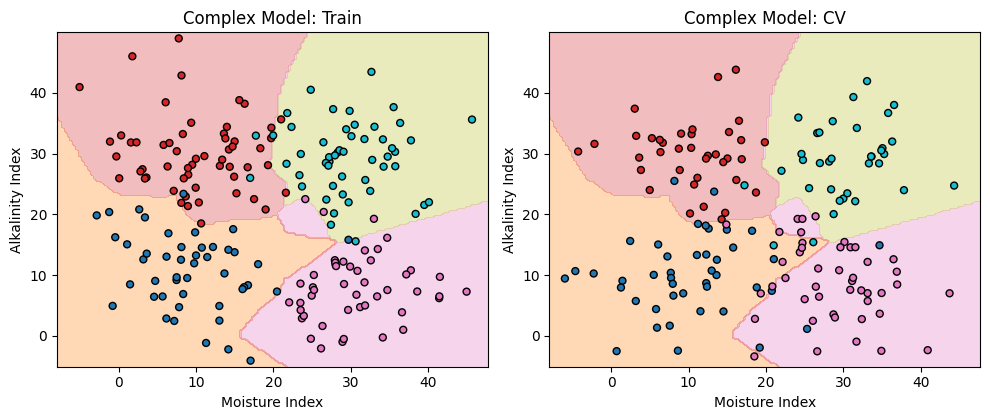

categorization error, training, complex model: 0.045
categorization error, cv,       complex model: 0.119


In [17]:
# wrap the model for the plotting/error-checking helpers
model_predict = lambda Xl: np.argmax(tf.nn.softmax(model.predict(Xl, verbose=0)).numpy(), axis=1)

plot_decision_boundary(model_predict, X_train, y_train, "Train", X_cv, y_cv, "CV", title="Complex Model")

training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
print(f"categorization error, training, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       complex model: {cv_cerr_complex:0.3f}")

The complex model has drawn a very intricate boundary that chases individual outliers in the
training set. That extra effort doesn't pay off on cross-validation data — a sign of **overfitting
/ high variance**.

<a name="5.2"></a>
### 5.2 Simple model

Now a much smaller network:
* Dense layer, 6 units, relu
* Dense layer, `classes` units, linear

Same loss and optimizer as before.

In [18]:
tf.random.set_seed(1234)
model_s = Sequential(
    [
        Dense(6, activation="relu", name="L1"),
        Dense(classes, activation="linear", name="L2"),
    ],
    name="Simple",
)
model_s.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)

model_s.fit(X_train, y_train, epochs=200, verbose=0)
model_s.summary()

Model: "Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 6)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 4)              │            28 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140 (564.00 B)

 Trainable params: 46 (184.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 94 (380.00 B)

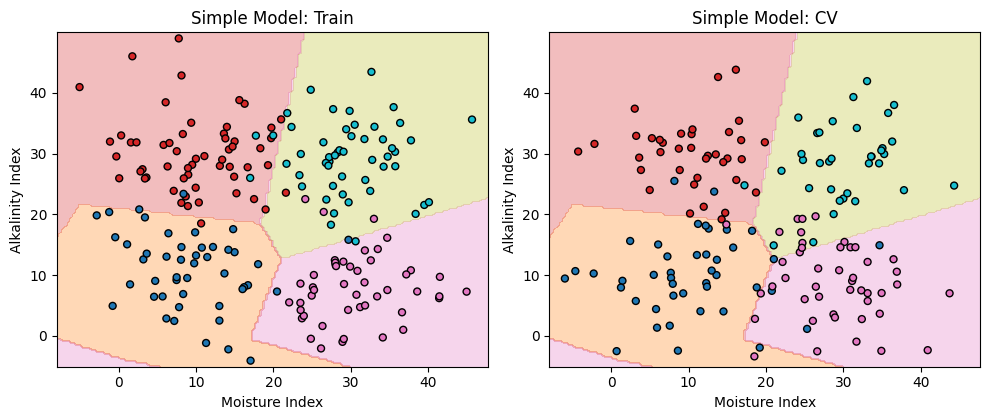

categorization error, training, simple model: 0.070, complex model: 0.045
categorization error, cv,       simple model: 0.094, complex model: 0.119


In [19]:
model_predict_s = lambda Xl: np.argmax(tf.nn.softmax(model_s.predict(Xl, verbose=0)).numpy(), axis=1)

plot_decision_boundary(model_predict_s, X_train, y_train, "Train", X_cv, y_cv, "CV", title="Simple Model")

training_cerr_simple = eval_cat_err(y_train, model_predict_s(X_train))
cv_cerr_simple = eval_cat_err(y_cv, model_predict_s(X_cv))
print(f"categorization error, training, simple model: {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       simple model: {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}")

The simple model's boundary is much smoother, its training error is a bit higher, but its
cross-validation error is *lower* than the complex model's — it generalizes better. This is the
bias/variance trade-off in action.

<a name="6"></a>
## 6 - Regularization for Neural Networks

Instead of shrinking the network, we can keep the complex architecture but add **L2
regularization** to discourage large weights (and therefore overly wiggly boundaries).

In [20]:
tf.random.set_seed(1234)
model_r = Sequential(
    [
        Dense(120, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.1), name="L1"),
        Dense(40, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.1), name="L2"),
        Dense(classes, activation="linear", name="L3"),
    ],
    name="ComplexRegularized",
)
model_r.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)

model_r.fit(X_train, y_train, epochs=200, verbose=0)

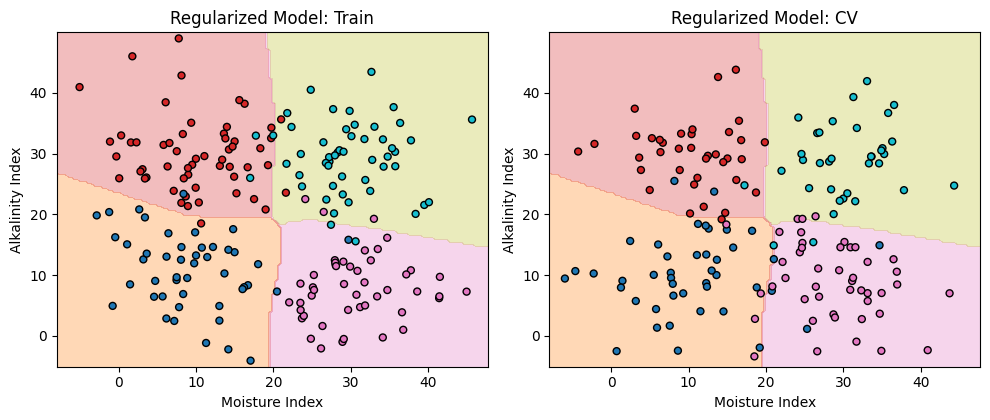

categorization error, training, regularized: 0.070, simple: 0.070, complex: 0.045
categorization error, cv,       regularized: 0.106, simple: 0.094, complex: 0.119


In [21]:
model_predict_r = lambda Xl: np.argmax(tf.nn.softmax(model_r.predict(Xl, verbose=0)).numpy(), axis=1)

plot_decision_boundary(model_predict_r, X_train, y_train, "Train", X_cv, y_cv, "CV", title="Regularized Model")

training_cerr_reg = eval_cat_err(y_train, model_predict_r(X_train))
cv_cerr_reg = eval_cat_err(y_cv, model_predict_r(X_cv))
print(f"categorization error, training, regularized: {training_cerr_reg:0.3f}, simple: {training_cerr_simple:0.3f}, complex: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       regularized: {cv_cerr_reg:0.3f}, simple: {cv_cerr_simple:0.3f}, complex: {cv_cerr_complex:0.3f}")

The regularized model's boundary looks close to the simple model's — smoother and less
distracted by outliers — while still using the larger architecture. Regularization gives us a way
to keep model capacity high while still controlling variance.

<a name="7"></a>
## 7 - Iterate to find the optimal regularization value

Just like we did for polynomial regression, we can scan across several regularization values and
pick the one that minimizes cross-validation error. **This cell trains 7 models and can take a
couple of minutes** — feel free to run it and inspect the results.

In [22]:
tf.random.set_seed(1234)
lambdas = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
models = [None] * len(lambdas)
err_train_nn = np.zeros(len(lambdas))
err_cv_nn = np.zeros(len(lambdas))

for i, lambda_ in enumerate(lambdas):
    models[i] = Sequential(
        [
            Dense(120, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(40, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(classes, activation="linear"),
        ]
    )
    models[i].compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(0.01),
    )
    models[i].fit(X_train, y_train, epochs=200, verbose=0)

    pred_fn = lambda Xl, m=models[i]: np.argmax(tf.nn.softmax(m.predict(Xl, verbose=0)).numpy(), axis=1)
    err_train_nn[i] = eval_cat_err(y_train, pred_fn(X_train))
    err_cv_nn[i] = eval_cat_err(y_cv, pred_fn(X_cv))
    print(f"finished lambda = {lambda_}  (train err {err_train_nn[i]:0.3f}, cv err {err_cv_nn[i]:0.3f})")

best_idx = np.argmin(err_cv_nn)
print(f"\nbest lambda: {lambdas[best_idx]}")

finished lambda = 0.0  (train err 0.045, cv err 0.138)


finished lambda = 0.001  (train err 0.050, cv err 0.150)


finished lambda = 0.01  (train err 0.055, cv err 0.113)


finished lambda = 0.05  (train err 0.060, cv err 0.106)


finished lambda = 0.1  (train err 0.070, cv err 0.100)


finished lambda = 0.2  (train err 0.065, cv err 0.106)


finished lambda = 0.3  (train err 0.070, cv err 0.106)

best lambda: 0.1


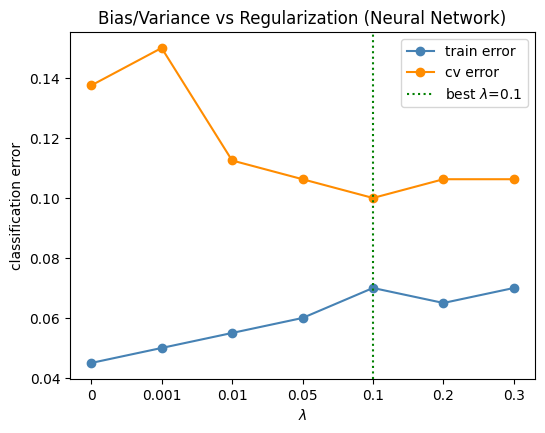

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
x_pos = np.arange(len(lambdas))
ax.plot(x_pos, err_train_nn, "o-", color="steelblue", label="train error")
ax.plot(x_pos, err_cv_nn, "o-", color="darkorange", label="cv error")
ax.axvline(best_idx, color="green", ls=":", label=f"best $\\lambda$={lambdas[best_idx]:g}")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{l:g}" for l in lambdas])
ax.set_xlabel("$\\lambda$")
ax.set_ylabel("classification error")
ax.set_title("Bias/Variance vs Regularization (Neural Network)")
ax.legend()
plt.show()

As regularization increases, training and cross-validation performance converge. For this
data set and architecture, a small-to-moderate $\lambda$ gives the best cross-validation error —
too little and the model overfits, too much and it starts to underfit.

<a name="7.1"></a>
### 7.1 Test

Finally, let's evaluate our best regularized model against the **test set** — data it has never
influenced in any way — and compare it with the simple model from Section 5.

test categorization error, complex model:        0.125
test categorization error, simple model:         0.100
test categorization error, best regularized (λ=0.1): 0.100


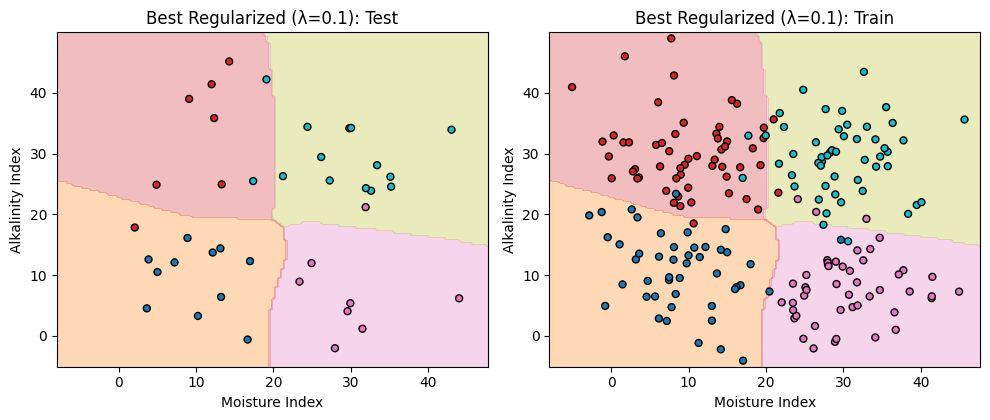

In [24]:
best_model = models[best_idx]
best_model_predict = lambda Xl: np.argmax(tf.nn.softmax(best_model.predict(Xl, verbose=0)).numpy(), axis=1)

test_cerr_best = eval_cat_err(y_test, best_model_predict(X_test))
test_cerr_simple = eval_cat_err(y_test, model_predict_s(X_test))
test_cerr_complex = eval_cat_err(y_test, model_predict(X_test))

print(f"test categorization error, complex model:        {test_cerr_complex:0.3f}")
print(f"test categorization error, simple model:         {test_cerr_simple:0.3f}")
print(f"test categorization error, best regularized (λ={lambdas[best_idx]:g}): {test_cerr_best:0.3f}")

plot_decision_boundary(best_model_predict, X_test, y_test, "Test", X_train, y_train, "Train", title=f"Best Regularized (λ={lambdas[best_idx]:g})")

## Wrap-up

In this notebook we practiced the core tools for evaluating and improving a machine learning
model, using two brand-new synthetic data sets (crop yield vs rainfall, and soil type from sensor
readings):

* Splitting data into **train** and **test** sets lets us tell the difference between underfitting
  and overfitting.
* Using **three** sets — training, cross-validation, and test — lets us:
    * fit parameters ($w, b$ or network weights) on the **training** set,
    * tune hyperparameters (polynomial degree, regularization $\lambda$, network architecture) on
      the **cross-validation** set,
    * get an honest, final estimate of real-world performance on the **test** set — touched only
      once, at the end.
* Comparing training vs. cross-validation performance reveals a model's tendency toward
  **overfitting (high variance)** or **underfitting (high bias)** — and both polynomial degree /
  network size *and* regularization strength can be tuned this way.
* When a model has **high variance**, collecting **more data** tends to help. When a model has
  **high bias**, more data alone won't fix it.

Feel free to fork this notebook, swap in your own data set, and re-run everything end-to-end.
